<a href="https://colab.research.google.com/github/gowardhanan440569/Flood-Prediction/blob/main/Rainfall_Spatial_Variation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import ee
import pandas as pd

# 1. Authenticate and Initialize Earth Engine with a Project ID
# Replace 'YOUR-PROJECT-ID' with your actual Earth Engine Cloud Project ID
PROJECT_ID = 'gen-lang-client-0316690358'

try:
    # Try to initialize directly if already authenticated
    ee.Initialize(project=PROJECT_ID)
    print("✅ Earth Engine Initialized.")
except Exception as e:
    print("Authentication required. Please follow the link below...")
    # This will trigger the Google Login popup
    ee.Authenticate()
    # Initialize again using your project after logging in
    ee.Initialize(project=PROJECT_ID)
    print("✅ Earth Engine Initialized.")

# ... (The rest of the script remains exactly the same starting from _BP = ...)

# 2. Define the Full Basin Polygon (Your exact coordinates)
_BP = [
    [79.65, 13.25], [79.70, 13.37], [79.85, 13.35],
    [80.00, 13.32], [80.15, 13.30], [80.22, 13.28],
    [80.32, 13.20], [80.32, 13.10], [80.30, 13.01],
    [80.28, 12.95], [80.15, 12.78], [79.98, 12.72],
    [79.85, 12.75], [79.75, 12.80], [79.65, 12.90],
    [79.65, 13.10], [79.65, 13.25]
]
basin_roi = ee.Geometry.Polygon(_BP)

# 3. Choose Climate Models (An ensemble for better accuracy)
models = ['ACCESS-CM2', 'MIROC6', 'MPI-ESM1-2-HR']

def process_and_export(scenario, start_year, end_year, filename):
    print(f"⚙️ Queuing task for: {filename}...")

    # Base collection
    collection = ee.ImageCollection("NASA/GDDP-CMIP6") \
        .filterBounds(basin_roi) \
        .filter(ee.Filter.eq('scenario', scenario)) \
        .filter(ee.Filter.inList('model', models)) \
        .filterDate(f'{start_year}-01-01', f'{end_year}-12-31') \
        .select('pr') # 'pr' is precipitation flux (kg/m2/s)

    # We need to map over years and months to get Monthly Sums
    years = ee.List.sequence(start_year, end_year)
    months = ee.List.sequence(1, 12)

    def by_model(model_name):
        model_col = collection.filter(ee.Filter.eq('model', model_name))

        def by_year(y):
            def by_month(m):
                # Filter to specific month and year
                filtered = model_col \
                    .filter(ee.Filter.calendarRange(y, y, 'year')) \
                    .filter(ee.Filter.calendarRange(m, m, 'month'))

                # Convert kg/m2/s to mm/day (multiply by 86400 seconds)
                # Then sum all days in the month to get total monthly rainfall in mm
                monthly_sum = filtered.map(lambda img: img.multiply(86400)).sum()

                # Format Date as YYYY-MM-DD
                date_str = ee.Date.fromYMD(y, m, 1).format('YYYY-MM-dd')

                return monthly_sum.set({
                    'model': model_name,
                    'year': y,
                    'month': m,
                    'date': date_str,
                    'system:time_start': ee.Date.fromYMD(y, m, 1).millis()
                })
            return months.map(by_month)
        return years.map(by_year).flatten()

    # Flatten the list of images into a single collection
    monthly_images = ee.ImageCollection(ee.List(models).map(by_model).flatten())

    # Sample the regions to convert spatial pixels to a tabular format (CSV)
    # Native resolution of GDDP is 0.25 degrees (~27km).
    # Your local Python script perfectly interpolates this down to 500m later!
    def sample_image(img):
        return img.sampleRegions(
            collection=ee.FeatureCollection(basin_roi),
            scale=27830, # ~0.25 degrees in meters
            geometries=True
        ).map(lambda feat: feat.copyProperties(img, ['model', 'year', 'month', 'date']))

    final_table = monthly_images.map(sample_image).flatten()

    # Export to Google Drive
    task = ee.batch.Export.table.toDrive(
        collection=final_table,
        description=filename,
        folder='CMIP6_Chennai_Basin',
        fileNamePrefix=filename,
        fileFormat='CSV',
        selectors=['date', 'year', 'month', 'model', 'pr', '.geo']
    )
    task.start()
    print(f"✅ Task '{filename}' sent to Earth Engine servers!")

# 4. Trigger the 3 Exports
process_and_export('historical', 1981, 2014, 'historical_CMIP6_spatial_1981_2020')
process_and_export('ssp245', 2015, 2040, 'ssp245_CMIP6_spatial_2021_2040')
process_and_export('ssp585', 2015, 2040, 'ssp585_CMIP6_spatial_2021_2040')

print("\n🚀 All tasks submitted! You can monitor their progress at:")
print("👉 https://code.earthengine.google.com/tasks")
print("Once finished, the CSV files will appear in a folder named 'CMIP6_Chennai_Basin' in your Google Drive.")

✅ Earth Engine Initialized.
⚙️ Queuing task for: historical_CMIP6_spatial_1981_2020...
✅ Task 'historical_CMIP6_spatial_1981_2020' sent to Earth Engine servers!
⚙️ Queuing task for: ssp245_CMIP6_spatial_2021_2040...
✅ Task 'ssp245_CMIP6_spatial_2021_2040' sent to Earth Engine servers!
⚙️ Queuing task for: ssp585_CMIP6_spatial_2021_2040...
✅ Task 'ssp585_CMIP6_spatial_2021_2040' sent to Earth Engine servers!

🚀 All tasks submitted! You can monitor their progress at:
👉 https://code.earthengine.google.com/tasks
Once finished, the CSV files will appear in a folder named 'CMIP6_Chennai_Basin' in your Google Drive.


✅ Imports done.
🗺️ Loading Shapefiles...
✅ Configuration set.
   Grid size    : (211, 239)
   Basin pixels : 24722 grid cells inside polygon
📥 Spatial CSV loaded
   Shape        : (1632, 7)
   Pixels       : 4
✅ Feature engineering done
🌲 Training per-pixel Random Forest …
🔁 Training per-pixel LSTM (seq_len=24) …

🔮 Rolling out forecast for 4 pixels (2015->2040) …
✅ Forecast complete

🎨 Generating requested spatial maps and saving TIFFs (2009, 2015, 2027, 2035)...


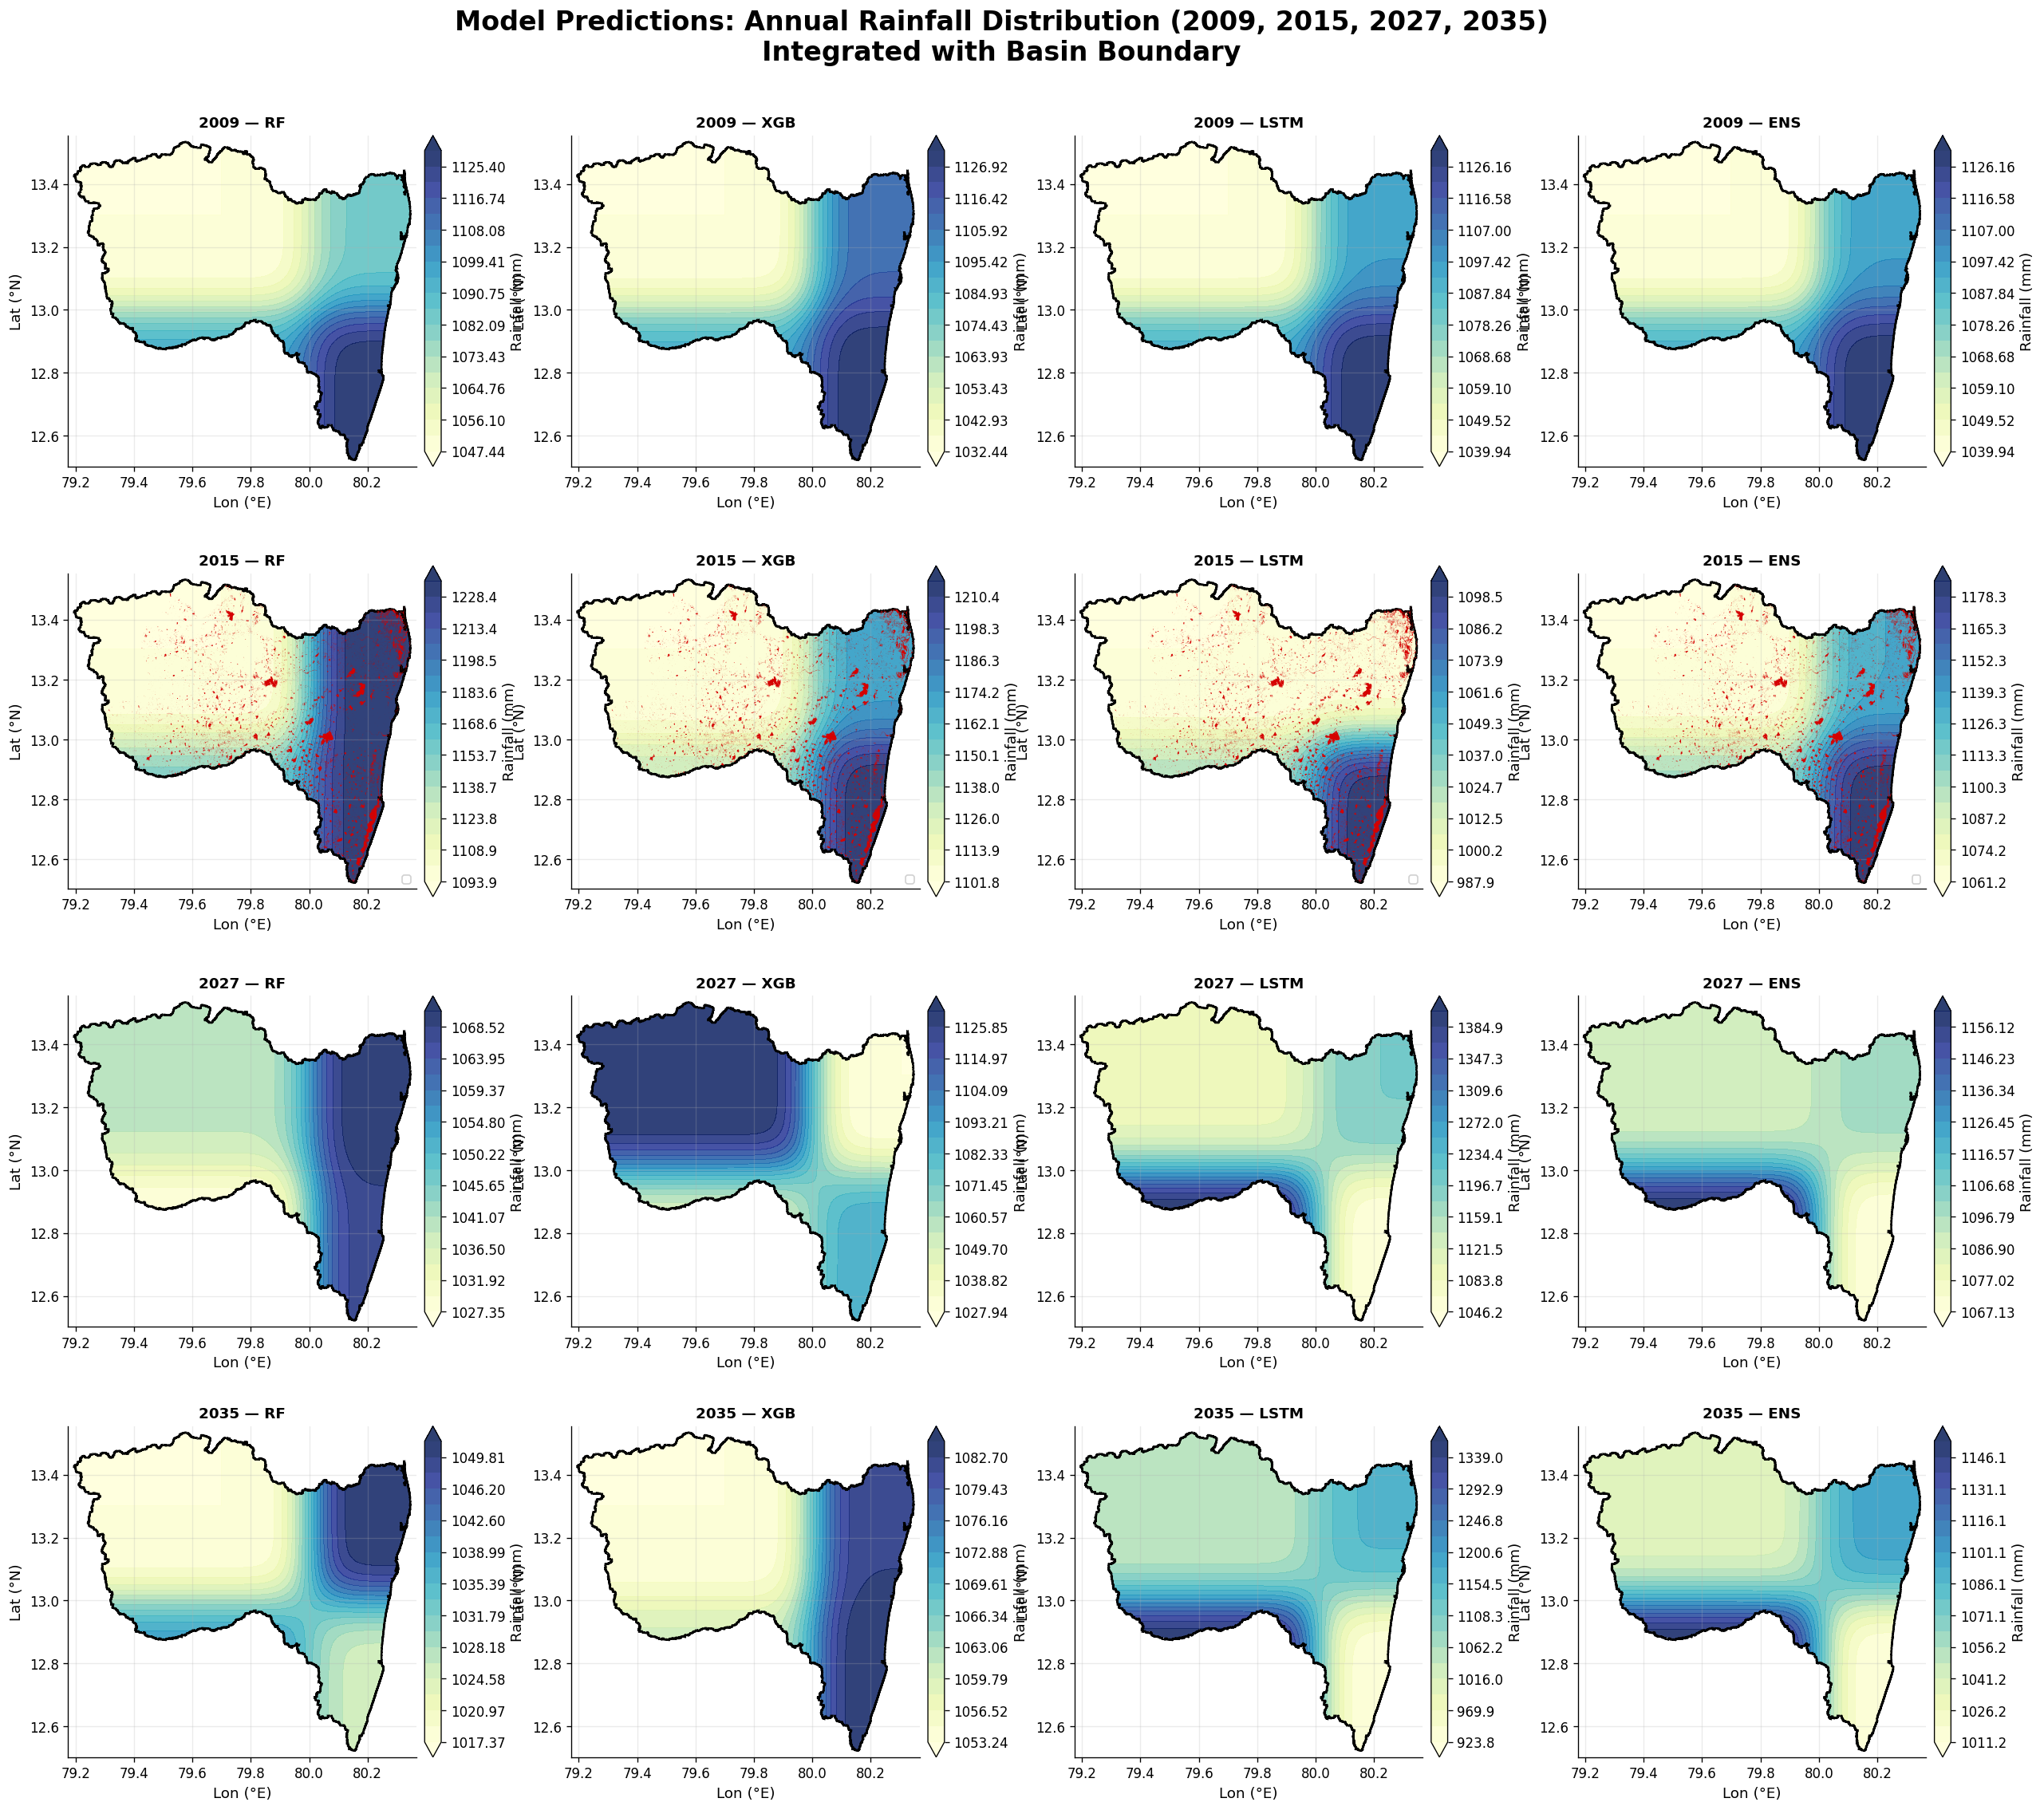

✅ Pipeline complete!
✅ Saved map image to: 04_shapefile_predictions_overlay.png
✅ Saved 16 geospatial datasets as .tif files (e.g. forecast_2027_LSTM.tif)


In [14]:
import os, math, json, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['SHAPE_RESTORE_SHX'] = 'YES' # Force GeoPandas to build missing .shx files

import numpy  as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from scipy.interpolate import griddata
from shapely.geometry  import Point, Polygon
from scipy.ndimage import gaussian_filter
from sklearn.ensemble       import RandomForestRegressor
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import (mean_squared_error, mean_absolute_error, r2_score)
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models   import Sequential
from tensorflow.keras.layers   import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# --- NEW: Rasterio for saving GeoTIFFs ---
try:
    import rasterio
    from rasterio.transform import from_origin
    HAS_RASTERIO = True
except ImportError:
    print("⚠️ Warning: 'rasterio' library is not installed. GeoTIFFs will not be saved.")
    print("   To fix, run: pip install rasterio")
    HAS_RASTERIO = False

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Colour constants & Plot Settings ─────────────────────────
C = {'RF': '#E63946', 'XGB': '#2A9D8F', 'LSTM': '#264653',
     'HIST': '#457B9D', 'FLOOD': '#F4A261'}
CMAP_RAIN = 'YlGnBu'

plt.rcParams.update({
    'figure.dpi'         : 120,
    'font.family'        : 'DejaVu Sans',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.grid'          : True,
    'grid.alpha'         : 0.25,
    'axes.labelsize'     : 11,
    'axes.titlesize'     : 11,
})
print('✅ Imports done.')

# ── File Paths ───────────────────────────────────────────────
HIST_FILE   = 'historical_CMIP6_spatial_1981_2020.csv'
SSP245_FILE = 'ssp245_CMIP6_spatial_2021_2040.csv'
SSP585_FILE = 'ssp585_CMIP6_spatial_2021_2040.csv'

# ── Temporal split ───────────────────────────────────────────
TRAIN_END   = 2009
VAL_START   = 2010
VAL_END     = 2014
WARMUP_YR   = 2015
FCAST_START = 2015     # Store results starting from here
FCAST_END   = 2040

# ── Model hyperparameters ────────────────────────────────────
SEQ_LEN          = 24
FLOOD_PERCENTILE = 95

# ── Load Shapefiles Safely ───────────────────────────────────
print('🗺️ Loading Shapefiles...')
def load_shape_safely(filepath):
    try:
        gdf = gpd.read_file(filepath)
        return gdf.to_crs(epsg=4326)
    except Exception as e:
        print(f" ⚠️ Warning: Skipped {filepath} due to corruption or missing files. ({e})")
        return None

basin_shp   = load_shape_safely('Chennaibasin_bound.shp')
streams_shp = load_shape_safely('Chennaibasin_Str.shp')
flood_shp   = load_shape_safely('Floodpoints_2015.shp')

# Fallback polygon if shapefile fails
_BP = [
    (79.65, 13.25), (79.70, 13.37), (79.85, 13.35), (80.00, 13.32), (80.15, 13.30),
    (80.22, 13.28), (80.32, 13.20), (80.32, 13.10), (80.30, 13.01), (80.28, 12.95),
    (80.15, 12.78), (79.98, 12.72), (79.85, 12.75), (79.75, 12.80), (79.65, 12.90),
    (79.65, 13.10), (79.65, 13.25)
]

if basin_shp is not None:
    basin_geom = basin_shp.geometry.iloc[0]
    if basin_geom.geom_type == 'MultiPolygon':
        basin_geom = max(basin_geom.geoms, key=lambda a: a.area)
    _TRUE_BP = list(basin_geom.exterior.coords)
    BASIN_POLY = basin_geom
else:
    _TRUE_BP = _BP
    BASIN_POLY = Polygon(_BP)

# ── DYNAMIC Interpolation grid (0.005° ≈ 500m resolution) ───
minx, miny, maxx, maxy = BASIN_POLY.bounds
PIXEL_SIZE = 0.005
_lon_arr = np.arange(minx - 0.02, maxx + 0.02, PIXEL_SIZE)
_lat_arr = np.arange(miny - 0.02, maxy + 0.02, PIXEL_SIZE)
GLON, GLAT = np.meshgrid(_lon_arr, _lat_arr)

_flat = np.column_stack([GLON.ravel(), GLAT.ravel()])
BASIN_MASK = np.array([BASIN_POLY.contains(Point(x, y)) for x, y in _flat]).reshape(GLON.shape)

print('✅ Configuration set.')
print(f'   Grid size    : {GLON.shape}')
print(f'   Basin pixels : {BASIN_MASK.sum()} grid cells inside polygon')

# ── Data Loading Functions ───────────────────────────────────
def _parse_geo(geo_str):
    try:
        g = json.loads(str(geo_str))
        c = g['coordinates']
        return float(c[0]), float(c[1])
    except Exception:
        return np.nan, np.nan

def load_spatial_csv(filepath):
    if not os.path.exists(filepath):
        print(f"⚠️ Warning: Could not find {filepath}. Make sure you uploaded it!")
        return pd.DataFrame()

    df = pd.read_csv(filepath)
    df = df.drop(columns=[c for c in df.columns if c in ['system:index', 'scenario', 'system:time_start']], errors='ignore')
    df.columns = [c.strip().lower().replace(' ', '_').replace(':', '_') for c in df.columns]

    if '.geo' in df.columns:
        lonlat = df['.geo'].apply(lambda x: pd.Series(_parse_geo(x), index=['lon', 'lat']))
        df = pd.concat([df.drop(columns=['.geo']), lonlat], axis=1)

    if 'date' in df.columns:
        df['Date'] = pd.to_datetime(df['date'].astype(str).str[:7] + '-01', format='%Y-%m-%d', errors='coerce')
    else:
        df['Date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2) + '-01')

    df['year']        = df['Date'].dt.year.astype(int)
    df['month']       = df['Date'].dt.month.astype(int)
    df['rainfall_mm'] = pd.to_numeric(df['rainfall_mm'], errors='coerce').clip(lower=0)

    if 'model' in df.columns and df['model'].nunique() > 1:
        df = df.groupby(['Date', 'year', 'month', 'lon', 'lat'])['rainfall_mm'].mean().reset_index()
    else:
        df = df.drop(columns=['model'], errors='ignore')

    coords = df[['lon', 'lat']].drop_duplicates().sort_values(['lat', 'lon']).reset_index(drop=True)
    coords['pixel_id'] = np.arange(len(coords), dtype=int)
    df = df.merge(coords, on=['lon', 'lat'], how='left')

    return df[['Date', 'year', 'month', 'pixel_id', 'lon', 'lat', 'rainfall_mm']].sort_values(['Date', 'pixel_id']).reset_index(drop=True)

# Load Historical
df_sp = load_spatial_csv(HIST_FILE)
if df_sp.empty:
    print("Cannot proceed without historical data.")
    exit()

df_sp = df_sp[df_sp['year'] <= 2014].reset_index(drop=True)
pixel_info = df_sp[['pixel_id', 'lon', 'lat']].drop_duplicates().sort_values('pixel_id').reset_index(drop=True)
N_PIX    = len(pixel_info)
N_MONTHS = df_sp['Date'].nunique()

print('📥 Spatial CSV loaded')
print(f'   Shape        : {df_sp.shape}')
print(f'   Pixels       : {N_PIX}')

# ── Mapping Functions ────────────────────────────────────────
def to_grid(lons, lats, vals):
    pts = np.column_stack([lons, lats])
    grid_pts = np.column_stack([GLON.ravel(), GLAT.ravel()])
    zi_nearest = griddata(pts, vals, grid_pts, method='nearest').reshape(GLON.shape)
    zi_smooth = gaussian_filter(zi_nearest, sigma=15)
    return np.where(BASIN_MASK, zi_smooth, np.nan)

def save_geotiff(zi, filename, lons, lats):
    """Saves the 2D numpy array as a GeoTIFF using the grid's spatial extent."""
    if not HAS_RASTERIO: return

    # In np.meshgrid(lons, lats), zi[0,:] is the bottom (min latitude).
    # GeoTIFFs expect row 0 to be the top (max latitude). Flip upside down.
    zi_flipped = np.flipud(zi)

    # Calculate top-left corner coordinates (shifted by half-pixel to get the edge)
    min_lon = lons[0] - (PIXEL_SIZE / 2)
    max_lat = lats[-1] + (PIXEL_SIZE / 2)

    # Create the affine transformation matrix
    transform = from_origin(min_lon, max_lat, PIXEL_SIZE, PIXEL_SIZE)

    # Convert NaNs to -9999.0 for standard GIS nodata
    zi_filled = np.nan_to_num(zi_flipped, nan=-9999.0)

    with rasterio.open(
        filename,
        'w',
        driver='GTiff',
        height=zi_filled.shape[0],
        width=zi_filled.shape[1],
        count=1,
        dtype=zi_filled.dtype,
        crs='EPSG:4326',
        transform=transform,
        nodata=-9999.0
    ) as dst:
        dst.write(zi_filled, 1)

def draw_map_with_shapefiles(ax, zi, title, year=None, cmap=CMAP_RAIN, vmin=None, vmax=None):
    if vmin is None: vmin = np.nanmin(zi)
    if vmax is None: vmax = np.nanmax(zi)
    levels = 15 if vmin == vmax else np.linspace(vmin, vmax, 20)

    im = ax.contourf(GLON, GLAT, zi, levels=levels, cmap=cmap, extend='both', alpha=0.85)

    # 1. Add clip path to mask the heatmap AND draw the basin outline
    clip_path = Path(_TRUE_BP)
    clip_patch = PathPatch(clip_path, transform=ax.transData, facecolor='none', edgecolor='black', linewidth=1.5, zorder=4)
    ax.add_patch(clip_patch)
    im.set_clip_path(clip_patch)

    # 2. Overlay Flood Points
    if year == 2015 and flood_shp is not None:
        flood_shp.plot(ax=ax, color='#D50000', marker='X', markersize=25, label='Recorded Floods', zorder=5)
        ax.legend(loc='lower right', fontsize=8, framealpha=0.9)

    plt.colorbar(im, ax=ax, label='Rainfall (mm)', pad=0.02)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Lon (°E)'); ax.set_ylabel('Lat (°N)')

    # Lock camera to bounds
    bx = [c[0] for c in _TRUE_BP]; by = [c[1] for c in _TRUE_BP]
    ax.set_xlim([min(bx) - 0.02, max(bx) + 0.02])
    ax.set_ylim([min(by) - 0.02, max(by) + 0.02])

# ── Feature Engineering ──────────────────────────────────────
_wide         = df_sp.pivot_table(values='rainfall_mm', index='Date', columns='pixel_id')
BASIN_MEAN_TS  = _wide.mean(axis=1)
_bm_lag1_map   = BASIN_MEAN_TS.shift(1).to_dict()

FEATURES = ['Month_sin', 'Month_cos', 'Year_norm', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_6', 'Lag_12', 'Roll_mean_3', 'Roll_mean_6', 'Roll_mean_12', 'Roll_std_3',  'Roll_std_12', 'Ann_cumsum', 'Basin_mean_lag1']
TARGET = 'rainfall_mm'
N_FEAT = len(FEATURES)

def build_features(pixel_id):
    d = df_sp[df_sp['pixel_id'] == pixel_id][['Date', 'year', 'month', 'rainfall_mm']].sort_values('Date').reset_index(drop=True)
    d['Month_sin'] = np.sin(2 * np.pi * d['month'] / 12)
    d['Month_cos'] = np.cos(2 * np.pi * d['month'] / 12)
    d['Year_norm'] = (d['year'] - 1981) / (2040 - 1981)
    for lag in [1, 2, 3, 6, 12]: d[f'Lag_{lag}'] = d['rainfall_mm'].shift(lag)
    s = d['rainfall_mm'].shift(1)
    d['Roll_mean_3']  = s.rolling(3).mean()
    d['Roll_mean_6']  = s.rolling(6).mean()
    d['Roll_mean_12'] = s.rolling(12).mean()
    d['Roll_std_3']   = s.rolling(3).std().fillna(0)
    d['Roll_std_12']  = s.rolling(12).std().fillna(0)
    d['Ann_cumsum'] = d.groupby('year')['rainfall_mm'].transform(lambda x: x.shift(1).cumsum().fillna(0))
    d['Basin_mean_lag1'] = d['Date'].map(_bm_lag1_map).fillna(0)
    return d.dropna().reset_index(drop=True)

pixel_dfs = {pid: build_features(pid) for pid in pixel_info['pixel_id']}
print('✅ Feature engineering done')

def split_pixel(pf):
    tr = pf[pf['year'] <= TRAIN_END].copy()
    v  = pf[(pf['year'] >= VAL_START) & (pf['year'] <= VAL_END)].copy()
    return tr[FEATURES].values, tr[TARGET].values, v[FEATURES].values, v[TARGET].values, v.reset_index(drop=True)

# ── Model Training ───────────────────────────────────────────
print('🌲 Training per-pixel Random Forest …')
RF_MODELS, XGB_MODELS, LSTM_MODELS = {}, {}, {}

for pid in pixel_info['pixel_id']:
    X_tr, y_tr, X_v, y_v, _ = split_pixel(pixel_dfs[pid])

    # RF
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=SEED)
    rf.fit(X_tr, np.log1p(y_tr))
    RF_MODELS[pid] = rf

    # XGB
    mdl = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=SEED, n_jobs=-1, verbosity=0)
    mdl.fit(X_tr, np.log1p(y_tr))
    XGB_MODELS[pid] = mdl

def _make_seqs(X_sc, y_log, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X_sc)):
        Xs.append(X_sc[i - seq_len : i])
        ys.append(y_log[i])
    return np.array(Xs), np.array(ys)

print(f'🔁 Training per-pixel LSTM (seq_len={SEQ_LEN}) …')
for pid in pixel_info['pixel_id']:
    pf = pixel_dfs[pid]
    X_raw = pf[FEATURES].values
    y_log = np.log1p(pf[TARGET].values)
    sc = StandardScaler().fit(X_raw[:len(pf[pf['year'] <= TRAIN_END])])
    X_sc = sc.transform(X_raw)
    Xs, ys = _make_seqs(X_sc, y_log, SEQ_LEN)

    m = Sequential([LSTM(32, input_shape=(SEQ_LEN, N_FEAT)), Dense(1)])
    m.compile(Adam(0.005), loss='mse')
    m.fit(Xs, ys, epochs=20, batch_size=32, verbose=0)
    LSTM_MODELS[pid] = (m, sc)

# ── Rollout Forecast ─────────────────────────────────────────
_ALL_FCAST_DATES = pd.date_range(f'{WARMUP_YR}-01-01', f'{FCAST_END}-12-01', freq='MS')

def rollout_pixel(pixel_id):
    hist = pixel_dfs[pixel_id].copy()
    buf = hist['rainfall_mm'].tolist()
    bm_hist = BASIN_MEAN_TS.reindex(hist['Date']).ffill().tolist()
    bm_buf  = bm_hist[:]

    lstm_model, lstm_sc = LSTM_MODELS[pixel_id]
    seed_rows = hist.tail(SEQ_LEN)[FEATURES].values
    lstm_win  = lstm_sc.transform(seed_rows).tolist()

    ann_cs = {}
    results = []

    for dt in _ALL_FCAST_DATES:
        yr, mo = dt.year, dt.month
        mo_sin, mo_cos = np.sin(2 * np.pi * mo / 12), np.cos(2 * np.pi * mo / 12)
        yr_n   = (yr - 1981) / (2040 - 1981)

        def _lag(k): return buf[-k] if len(buf) >= k else 0.0
        lag1, lag2, lag3, lag6, lag12 = _lag(1), _lag(2), _lag(3), _lag(6), _lag(12)

        buf3, buf6, buf12 = buf[-3:], buf[-6:], buf[-12:]
        rm3, rm6, rm12 = float(np.mean(buf3)), float(np.mean(buf6)), float(np.mean(buf12))
        rs3, rs12 = float(np.std(buf3) if len(buf3)>1 else 0), float(np.std(buf12) if len(buf12)>1 else 0)

        if mo == 1: ann_cs[yr] = 0.0
        ac = ann_cs.get(yr, 0.0)
        bm_lag1 = bm_buf[-1] if bm_buf else 0.0

        feat = np.array([[mo_sin, mo_cos, yr_n, lag1, lag2, lag3, lag6, lag12, rm3, rm6, rm12, rs3, rs12, ac, bm_lag1]])

        rf_pred = float(np.maximum(np.expm1(RF_MODELS[pixel_id].predict(feat)[0]), 0))
        xgb_pred = float(np.maximum(np.expm1(XGB_MODELS[pixel_id].predict(feat)[0]), 0))

        feat_sc = lstm_sc.transform(feat)[0].tolist()
        lstm_win.append(feat_sc)
        if len(lstm_win) > SEQ_LEN: lstm_win.pop(0)

        if len(lstm_win) == SEQ_LEN:
            seq_in = np.array(lstm_win).reshape(1, SEQ_LEN, N_FEAT)
            lstm_pred = float(np.maximum(np.expm1(lstm_model.predict(seq_in, verbose=0)[0, 0]), 0))
        else:
            lstm_pred = (rf_pred + xgb_pred) / 2

        ens_pred = (rf_pred + xgb_pred + lstm_pred) / 3
        buf.append(ens_pred); bm_buf.append(ens_pred)
        ann_cs[yr] = ann_cs.get(yr, 0.0) + ens_pred

        if yr >= FCAST_START:
            results.append({'Date': dt, 'year': yr, 'month': mo, 'RF': rf_pred, 'XGB': xgb_pred, 'LSTM': lstm_pred, 'ENS': ens_pred})

    return pd.DataFrame(results)

print(f'\n🔮 Rolling out forecast for {N_PIX} pixels ({WARMUP_YR}->{FCAST_END}) …')
FCAST_PIX = {pid: rollout_pixel(pid) for pid in pixel_info['pixel_id']}
print('✅ Forecast complete')

# ── Generate Specific Year Predictions & Images & TIFFs ──
print('\n🎨 Generating requested spatial maps and saving TIFFs (2009, 2015, 2027, 2035)...')

hist_years = [2009]
fcast_years = [2015, 2027, 2035]
target_years = hist_years + fcast_years
model_names = ['RF', 'XGB', 'LSTM', 'ENS']

data_maps = {y: {m: [] for m in model_names} for y in target_years}
lon_list = pixel_info['lon'].tolist()
lat_list = pixel_info['lat'].tolist()

for pid in pixel_info['pixel_id']:
    df_hist = pixel_dfs[pid]
    for y in hist_years:
        df_y = df_hist[df_hist['year'] == y]
        if not df_y.empty:
            X_feats = df_y[FEATURES].values
            rf_p = np.maximum(np.expm1(RF_MODELS[pid].predict(X_feats)), 0).sum()
            xgb_p = np.maximum(np.expm1(XGB_MODELS[pid].predict(X_feats)), 0).sum()
            lstm_model, lstm_sc = LSTM_MODELS[pid]
            X_sc = lstm_sc.transform(X_feats)
            seqs, _ = _make_seqs(X_sc, np.zeros(len(X_sc)), SEQ_LEN)
            if len(seqs) > 0:
                lstm_p = np.maximum(np.expm1(lstm_model.predict(seqs, verbose=0).ravel()), 0).sum()
            else:
                lstm_p = (rf_p + xgb_p) / 2
            ens_p = (rf_p + xgb_p + lstm_p) / 3
        else:
            rf_p, xgb_p, lstm_p, ens_p = np.nan, np.nan, np.nan, np.nan

        data_maps[y]['RF'].append(rf_p); data_maps[y]['XGB'].append(xgb_p)
        data_maps[y]['LSTM'].append(lstm_p); data_maps[y]['ENS'].append(ens_p)

    fdf = FCAST_PIX.get(pid, pd.DataFrame())
    for y in fcast_years:
        df_y = fdf[fdf['year'] == y]
        if not df_y.empty:
            data_maps[y]['RF'].append(df_y['RF'].sum()); data_maps[y]['XGB'].append(df_y['XGB'].sum())
            data_maps[y]['LSTM'].append(df_y['LSTM'].sum()); data_maps[y]['ENS'].append(df_y['ENS'].sum())
        else:
            data_maps[y]['RF'].append(np.nan); data_maps[y]['XGB'].append(np.nan)
            data_maps[y]['LSTM'].append(np.nan); data_maps[y]['ENS'].append(np.nan)

# Plotting the 4x4 Grid
fig = plt.figure(figsize=(26, 22))
fig.suptitle('Model Predictions: Annual Rainfall Distribution (2009, 2015, 2027, 2035)\nIntegrated with Basin Boundary',
             fontsize=20, fontweight='bold', y=0.94)
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.3, wspace=0.2)

bx, by = [c[0] for c in _TRUE_BP], [c[1] for c in _TRUE_BP]
xlim_bounds, ylim_bounds = [min(bx) - 0.02, max(bx) + 0.02], [min(by) - 0.02, max(by) + 0.02]

for row_idx, year in enumerate(target_years):
    for col_idx, model in enumerate(model_names):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        z_vals, lons, lats = np.array(data_maps[year][model], dtype=float), np.array(lon_list), np.array(lat_list)
        valid_mask = ~np.isnan(z_vals)

        if not valid_mask.any():
            ax.text(0.5, 0.5, f"No data for {year}", ha='center', va='center', color='red', fontsize=12, transform=ax.transAxes)
            ax.set_title(f'{year} — {model}', fontweight='bold')
            ax.set_xlim(xlim_bounds); ax.set_ylim(ylim_bounds); ax.axis('off')
            continue

        valid_lons, valid_lats, valid_z = lons[valid_mask], lats[valid_mask], z_vals[valid_mask]
        zi = to_grid(valid_lons, valid_lats, valid_z)

        if np.isnan(zi).all():
            ax.text(0.5, 0.5, f"Interpolation failed", ha='center', va='center', color='red', transform=ax.transAxes)
            ax.set_title(f'{year} — {model}', fontweight='bold')
            ax.set_xlim(xlim_bounds); ax.set_ylim(ylim_bounds); ax.axis('off')
            continue

        # --- SAVE AS GEOTIFF ---
        tif_filename = f"forecast_{year}_{model}.tif"
        save_geotiff(zi, tif_filename, _lon_arr, _lat_arr)

        vmin, vmax = np.nanmin(zi), np.nanmax(zi)
        title = f'{year} — {model}'
        draw_map_with_shapefiles(ax, zi, title, year, cmap=CMAP_RAIN, vmin=vmin, vmax=vmax)

plt.savefig('04_shapefile_predictions_overlay.png', dpi=250, bbox_inches='tight')
plt.show()
print('✅ Pipeline complete!')
print('✅ Saved map image to: 04_shapefile_predictions_overlay.png')
if HAS_RASTERIO:
    print('✅ Saved 16 geospatial datasets as .tif files (e.g. forecast_2027_LSTM.tif)')